# Getting R007 (National Interbank Funding Center)

In [60]:
import os
import akshare as ak
import pandas as pd
import time
import numpy as np


os.chdir('/Users/liminglin/我的云端硬盘 (liminglin1998@gmail.com)/Sciences Po/Thesis/Data')
print("Current Directory:", os.getcwd())


Current Directory: /Users/liminglin/我的云端硬盘 (liminglin1998@gmail.com)/Sciences Po/Thesis/Data


In [10]:
# 1. Create a list of years to loop through
years = range(2000, 2025)  # From 2000 up to (but not including) 2025
all_data = []

print("Starting download loop...")

for year in years:
    start_date = f"{year}0101"
    end_date = f"{year}1231"
    
    print(f"Fetching data for {year}...")
    
    try:
        # Fetch data for the specific year
        df = ak.repo_rate_hist(start_date=start_date, end_date=end_date)
        
        # Optional: Add a 'Year' column if you want to track it explicitly
        # df['Year'] = year 
        
        all_data.append(df)
        
        # Pause briefly to be polite to the server (prevents blocking)
        time.sleep(1) 
        
    except Exception as e:
        print(f"Error fetching data for {year}: {e}")
        # Continue to the next year even if one fails

# 2. Combine all years into one DataFrame
if all_data:
    full_repo_df = pd.concat(all_data, ignore_index=True)
    
    # 3. Clean duplicates (just in case) and Sort
    # The date column name might vary slightly; usually it is 'date' or '日期'
    # Check the column names if sort fails.
    if '日期' in full_repo_df.columns:
        full_repo_df.rename(columns={'日期': 'date'}, inplace=True)
        
    full_repo_df['date'] = pd.to_datetime(full_repo_df['date'])
    full_repo_df.sort_values('date', inplace=True)
    
    # 4. Filter for R007 specifically
    # The column for the rate might be '收盘' (Close) or similar.
    # Often the dataframe contains multiple repo types. 
    # If the output contains a "symbol" or "code" column, filter for "R-007" or similar.
    # (Inspect full_repo_df.head() to be sure of the column name for 7-day repo)

    print("Download Complete!")
    print(full_repo_df.head())
    print(f"Total rows: {len(full_repo_df)}")
    

else:
    print("No data fetched.")


Starting download loop...
Fetching data for 2000...
Fetching data for 2001...
Fetching data for 2002...
Fetching data for 2003...
Fetching data for 2004...
Fetching data for 2005...
Fetching data for 2006...
Fetching data for 2007...
Fetching data for 2008...
Fetching data for 2009...
Fetching data for 2010...
Fetching data for 2011...
Fetching data for 2012...
Fetching data for 2013...
Fetching data for 2014...
Fetching data for 2015...
Fetching data for 2016...
Fetching data for 2017...
Fetching data for 2018...
Fetching data for 2019...
Fetching data for 2020...
Fetching data for 2021...
Fetching data for 2022...
Fetching data for 2023...
Fetching data for 2024...
Download Complete!
        date  FR001  FR007  FR014  FDR001  FDR007  FDR014
0 2000-01-04    NaN   2.57    NaN     NaN     NaN     NaN
1 2000-01-05    NaN   2.56    NaN     NaN     NaN     NaN
2 2000-01-06    NaN   2.57    NaN     NaN     NaN     NaN
3 2000-01-07    NaN   2.58    NaN     NaN     NaN     NaN
4 2000-01-10   

In [11]:
full_repo_df['date'] = pd.to_datetime(full_repo_df['date'])


In [12]:
full_repo_df['quarter'] = full_repo_df['date'].dt.to_period('Q')
china_r007_df = full_repo_df.groupby('quarter')['FR007'].mean().reset_index()
china_r007_df['quarter'] = china_r007_df['quarter'].astype(str)

print(china_r007_df.head())

  quarter     FR007
0  2000Q1  2.506311
1  2000Q2  2.398145
2  2000Q3  2.332576
3  2000Q4  2.360902
4  2001Q1  2.501951


In [33]:
china_r007_df

,quarter,FR007
0,2000Q1,2.506311
1,2000Q2,2.398145
2,2000Q3,2.332576
3,2000Q4,2.360902
4,2001Q1,2.501951
...,...,...
95,2023Q4,2.365995
96,2024Q1,2.119761
97,2024Q2,1.937419
98,2024Q3,1.907424


# Getting CPI (OECD)

In [27]:
cpi_df = pd.read_csv('CPALTT01CNQ659N.csv')


In [29]:
cpi_df.columns = ['date','cpi']

In [30]:
# 1. Ensure your date column is actually a datetime object
cpi_df['date'] = pd.to_datetime(cpi_df['date'])

# 2. Create a new column with the Quarter format (Period Object)
# This automatically handles the conversion to "1996Q1", "1996Q2", etc.
cpi_df['quarter'] = cpi_df['date'].dt.to_period('Q')

# Optional: If you strictly need the column to be a String ("1996Q1") and not a Period Object
china_cpi_quarterly['quarter'] = china_cpi_quarterly['quarter'].astype(str)



In [31]:
cpi_df

,date,cpi,quarter
0,1994-01-01,22.236480,1994Q1
1,1994-04-01,21.867150,1994Q2
2,1994-07-01,25.725840,1994Q3
3,1994-10-01,26.883720,1994Q4
4,1995-01-01,22.583500,1995Q1
...,...,...,...
120,2024-01-01,-0.032185,2024Q1
121,2024-04-01,0.226831,2024Q2
122,2024-07-01,0.484653,2024Q3
123,2024-10-01,0.194175,2024Q4


In [ ]:
china_cpi_quarterly

# Cleaning GDP (Atlanta Fed)

In [49]:
gdp_df = pd.read_excel('QuarterlyChinaGDPDataset.xlsx', sheet_name='Data')


In [50]:
gdp_df_subset = gdp_df[["timeQtr", "NGDP_exp_Q_SA", "RGDP_exp_Q_SA"]]

In [51]:
def decimal_to_quarter(val):
    year = int(val)
    fraction = val - year

    quarter = int((fraction + 0.01) * 4) + 1
    
    return f"{year}Q{quarter}"

# 3. Apply it to create a new column
china_gdp_quarterly = gdp_df_subset.copy()
china_gdp_quarterly['date'] = china_gdp_quarterly['timeQtr'].apply(decimal_to_quarter)

china_gdp_quarterly = china_gdp_quarterly[['date', 'NGDP_exp_Q_SA', 'RGDP_exp_Q_SA']]  


In [52]:
china_gdp_quarterly['quarter'] = china_gdp_quarterly['date'].astype(str)

In [53]:
china_gdp_quarterly = china_gdp_quarterly.rename(columns={'NGDP_exp_Q_SA': 'ngdp', 'RGDP_exp_Q_SA': 'rgdp'})

In [54]:
china_gdp_quarterly = china_gdp_quarterly.drop(columns=['date'])

In [55]:
china_gdp_quarterly['ngdp_growth'] = china_gdp_quarterly['ngdp'].pct_change(periods=4) * 100
china_gdp_quarterly['rgdp_growth'] = china_gdp_quarterly['rgdp'].pct_change(periods=4) * 100

In [56]:
china_gdp_quarterly

,ngdp,rgdp,quarter,ngdp_growth,rgdp_growth
0,2444.000469,3481.713691,2000Q1,NaN,NaN
1,2473.976004,3503.331605,2000Q2,NaN,NaN
2,2503.902814,3532.980807,2000Q3,NaN,NaN
3,2557.406253,3583.202268,2000Q4,NaN,NaN
4,2634.372835,3648.582610,2001Q1,7.789375,4.792724
...,...,...,...,...,...
91,30226.716862,20989.897224,2022Q4,1.777767,2.151453
92,31175.558622,21585.587211,2023Q1,4.388015,3.962126
93,31193.856984,21730.307840,2023Q2,4.622558,5.367899
94,31530.700694,22021.077332,2023Q3,3.916370,4.962712


# Combining all three data

In [34]:
from functools import reduce


In [57]:
china_r007_df['quarter'] = china_r007_df['quarter'].astype(str)
cpi_df['quarter'] = cpi_df['quarter'].astype(str)
china_gdp_quarterly['quarter'] = china_gdp_quarterly['quarter'].astype(str)

In [79]:

# 1. Put your dataframes in a list
dfs = [china_r007_df, cpi_df, china_gdp_quarterly]

# 2. Define a merging function (Inner Join = Intersection of dates)
# This keeps only rows where 'quarter' exists in ALL dataframes
df_final = reduce(lambda left, right: pd.merge(left, right, on='quarter', how='inner'), dfs)

# 3. specific cleanup
# Set quarter as the index and sort it chronologically
df_final = df_final.set_index('quarter').sort_index()

# 4. Check the new timeframe
print(f"Start Date: {df_final.index.min()}")
print(f"End Date:   {df_final.index.max()}")


Start Date: 2000Q1
End Date:   2023Q4


In [80]:
df_final = df_final.drop(columns=['date', 'ngdp', 'rgdp'])
df_final

,FR007,cpi,ngdp_growth,rgdp_growth
quarter,,,,
2000Q1,2.506311,0.100897,NaN,NaN
2000Q2,2.398145,0.096920,NaN,NaN
2000Q3,2.332576,0.264006,NaN,NaN
2000Q4,2.360902,0.930059,NaN,NaN
2001Q1,2.501951,0.663740,7.789375,4.792724
...,...,...,...,...
2022Q4,1.959084,1.839685,1.777767,2.151453
2023Q1,2.257852,1.238188,4.388015,3.962126
2023Q2,2.100879,0.097308,4.622558,5.367899


In [81]:
df_final = df_final.reset_index()

In [82]:
df_final['quarter'] = df_final['quarter'].astype(str)

# Adding Inflation and RGDP Target

In [99]:

# 1. Define the targets (Midpoints used for ranges)
# Source: Government Work Reports
china_gdp_targets = {
    2000: 7.0, 2001: 7.0, 2002: 7.0, 2003: 7.0, 2004: 7.0,
    2005: 8.0, 2006: 8.0, 2007: 8.0, 2008: 8.0, 2009: 8.0,
    2010: 8.0, 2011: 8.0, 2012: 7.5, 2013: 7.5, 2014: 7.5,
    2015: 7.0, 
    2016: 6.75, # Range 6.5-7.0 -> Midpoint 6.75
    2017: 6.5, 
    2018: 6.5, 
    2019: 6.25, # Range 6.0-6.5 -> Midpoint 6.25
    2020: 6.0, # No official target set Set to 6.0 for calculation
    2021: 6.0,  # "Above 6.0" -> Treated as 6.0 baseline
    2022: 5.5, 
    2023: 5.0
}

china_cpi_targets = {
    2000: 2.0, 2001: 1.5, 2002: 1.5, 2003: 1.0, 2004: 3.0,
    2005: 4.0, 2006: 3.0, 2007: 3.0, 2008: 4.8, 2009: 4.0,
    2010: 3.0, 2011: 4.0, 2012: 4.0, 2013: 3.5, 2014: 3.5,
    2015: 3.0, 2016: 3.0, 2017: 3.0, 2018: 3.0, 2019: 3.0,
    2020: 3.5, 2021: 3.0, 2022: 3.0, 2023: 3.0
}

years = df_final['quarter'].str[:4].astype(int)
# 2. Extract the year from your PeriodIndex (assuming index is '2000Q1' etc.)
# If your index is named something else, change 'df_final.index'
df_final['target_gdp'] = years.map(china_gdp_targets)
df_final['target_cpi'] = years.map(china_cpi_targets)

# 4. Calculate the Gap immediately
df_final['gdp_gap'] = df_final['ngdp_growth'] - df_final['target_gdp']
df_final['cpi_gap'] = df_final['cpi'] - df_final['target_cpi']


In [100]:
df_final = df_final.reset_index()
df_final['quarter'] = df_final['quarter'].astype(str)
display(df_final[['quarter', 'target_gdp', 'gdp_gap', 'target_cpi', 'cpi_gap']].head())

,quarter,target_gdp,gdp_gap,target_cpi,cpi_gap
0,2000Q1,7.0,NaN,2.0,-1.899104
1,2000Q2,7.0,NaN,2.0,-1.903080
2,2000Q3,7.0,NaN,2.0,-1.735994
3,2000Q4,7.0,NaN,2.0,-1.069941
4,2001Q1,7.0,0.789375,1.5,-0.836260


In [ ]:
df_final

# Running the Regime Switch Regression (following Chen et.al 2025)

In [101]:
import stata_setup
stata_setup.config('/Applications/StataNow', 'mp')
from pystata import stata

In [139]:
stata.run("""
    clear all
    """)


. 
.     clear all

.     
. 


In [140]:
stata.pdataframe_to_data(df_final, force=True)


In [141]:

# Run the Stata code block directly in Python
stata.run("""
    generate date_stata = quarterly(quarter, "YQ")
    format date_stata %tq
    tsset date_stata
    """)



. 
.     generate date_stata = quarterly(quarter, "YQ")

.     format date_stata %tq

.     tsset date_stata

Time variable: date_stata, 2000q1 to 2023q4
        Delta: 1 quarter

.     
. 


In [142]:
stata.run(""" 
    gen shortfall = (gdp_gap < 0)
    gen gdp_gap_pos = gdp_gap * (1 - shortfall)
    gen gdp_gap_neg = gdp_gap * shortfall
    
    reg FR007 L.FR007 cpi_gap gdp_gap_pos gdp_gap_neg, robust
""")


.  
.     gen shortfall = (gdp_gap < 0)

.     gen gdp_gap_pos = gdp_gap * (1 - shortfall)
(4 missing values generated)

.     gen gdp_gap_neg = gdp_gap * shortfall
(4 missing values generated)

.     
.     reg FR007 L.FR007 cpi_gap gdp_gap_pos gdp_gap_neg, robust

Linear regression                               Number of obs     =         92
                                                F(4, 87)          =      49.15
                                                Prob > F          =     0.0000
                                                R-squared         =     0.7534
                                                Root MSE          =     .40653

------------------------------------------------------------------------------
             |               Robust
       FR007 | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
       FR007 |
         L1. |   .7712191   .0786545     9.81   

In [143]:
stata.run("""
    capture drop fr007_hat
    predict fr007_hat 
    replace fr007_hat = . if date_stata < yq(2001, 1)
    """)


. 
.     capture drop fr007_hat

.     predict fr007_hat 
(option xb assumed; fitted values)
(4 missing values generated)

.     replace fr007_hat = . if date_stata < yq(2001, 1)
(0 real changes made)

.     
. 


In [146]:
df_plot = stata.pdataframe_from_data(var=['quarter', 'FR007', 'fr007_hat'])
# 2. CLEANUP: Replace Stata's "Massive Missing Numbers" with Python's NaN
# We replace actual Infinity AND any value larger than 50% (since interest rates can't be that high)
df_plot['fr007_hat'] = df_plot['fr007_hat'].replace([np.inf, -np.inf], np.nan)
df_plot.loc[df_plot['fr007_hat'] > 50, 'fr007_hat'] = np.nan

# 3. Setup Index
df_plot['quarter'] = pd.PeriodIndex(df_plot['quarter'], freq='Q')
df_plot = df_plot.set_index('quarter').sort_index()
df_plot

,FR007,fr007_hat
quarter,,
2000Q1,2.506311,NaN
2000Q2,2.398145,NaN
2000Q3,2.332576,NaN
2000Q4,2.360902,NaN
2001Q1,2.501951,2.469096
...,...,...
2022Q4,1.959084,1.484987
2023Q1,2.257852,2.031375
2023Q2,2.100879,2.197659


<Figure size 1200x600 with 0 Axes>

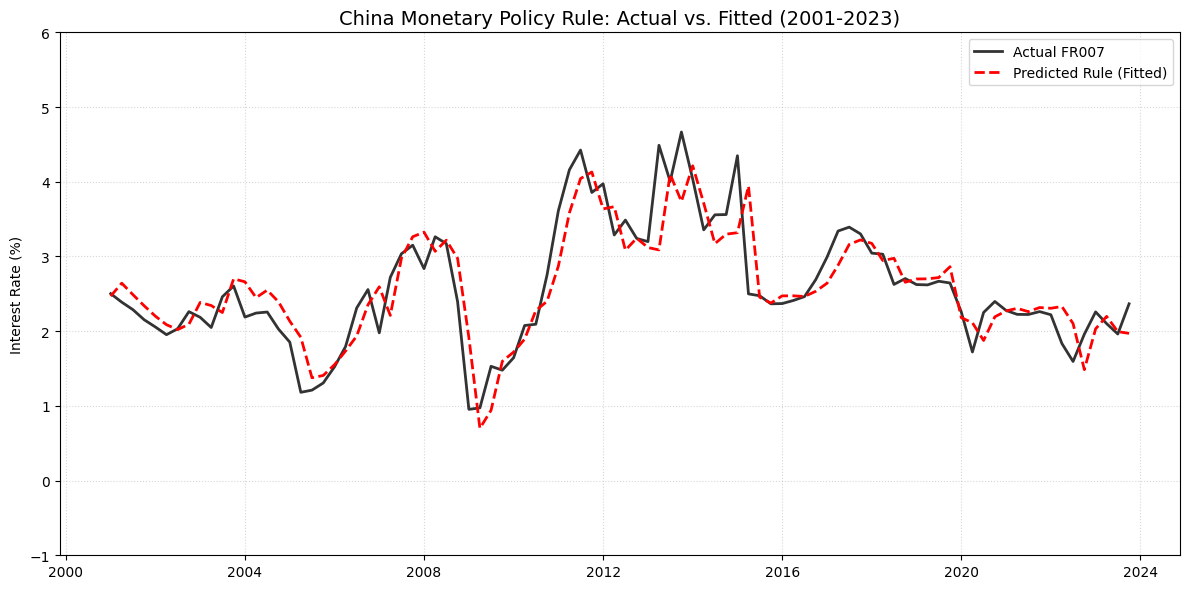

In [160]:
#4. Plot (Now safe)
plt.figure(figsize=(12, 6))
df_zoom = df_plot.loc['2001Q1':'2023Q4']

# 3. PLOT
plt.figure(figsize=(12, 6))

# Plot Actual FR007 (Using the zoomed data)
plt.plot(df_zoom.index.to_timestamp(), df_zoom['FR007'], 
         label='Actual FR007', color='black', linewidth=2, alpha=0.8)

# Plot Predicted Rule
plt.plot(df_zoom.index.to_timestamp(), df_zoom['fr007_hat'], 
         label='Predicted Rule (Fitted)', color='red', linestyle='--', linewidth=2)
plt.title('China Monetary Policy Rule: Actual vs. Fitted (2001-2023)', fontsize=14)
plt.ylabel('Interest Rate (%)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)

# Force the Y-Axis to look normal just in case (e.g., 0% to 10%)
plt.ylim(bottom=-1, top=6)

plt.tight_layout()
plt.savefig("Monetary Policy Rule_Chen.png", dpi=300)
plt.show()

In [150]:
# Run VIF test in Stata
stata.run("""
    quietly reg FR007 L.FR007 cpi_gap gdp_gap_pos gdp_gap_neg if tin(2001q1, 2023q4)
    estat vif
""")


. 
.     quietly reg FR007 L.FR007 cpi_gap gdp_gap_pos gdp_gap_neg if tin(2001q1, 
> 2023q4)

.     estat vif

    Variable |       VIF       1/VIF  
-------------+----------------------
 gdp_gap_pos |      1.94    0.515979
     cpi_gap |      1.90    0.526899
       FR007 |
         L1. |      1.34    0.747171
 gdp_gap_neg |      1.23    0.814544
-------------+----------------------
    Mean VIF |      1.60

. 


In [151]:
stata.run("""
    // 1. Create Real Interest Rate (Nominal - Inflation)
    // Ensure you use the quarterly YoY inflation rate
    gen real_rate = FR007 - cpi

    // 2. Run Regression on Real Rate
    newey real_rate L.real_rate gdp_gap_pos gdp_gap_neg if tin(2001q1, 2023q4), lag(4)
""")


. 
.     // 1. Create Real Interest Rate (Nominal - Inflation)
.     // Ensure you use the quarterly YoY inflation rate
.     gen real_rate = FR007 - cpi

. 
.     // 2. Run Regression on Real Rate
.     newey real_rate L.real_rate gdp_gap_pos gdp_gap_neg if tin(2001q1, 2023q4
> ), lag(4)

Regression with Newey–West standard errors      Number of obs     =         92
Maximum lag = 4                                 F(  3,        88) =      83.02
                                                Prob > F          =     0.0000

------------------------------------------------------------------------------
             |             Newey–West
   real_rate | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
   real_rate |
         L1. |   .6857098   .0603188    11.37   0.000     .5658388    .8055808
             |
 gdp_gap_pos |  -.1163477   .0298019    -3.90   0.000    -.1755727   -.0571227
 gdp_ga

In [162]:
stata.run("""
    // Run without the lag to isolate the "Gap Effect"
    reg FR007 cpi_gap gdp_gap_pos gdp_gap_neg if tin(2001q1, 2023q4), robust
""")


. 
.     // Run without the lag to isolate the "Gap Effect"
.     reg FR007 cpi_gap gdp_gap_pos gdp_gap_neg if tin(2001q1, 2023q4), robust

Linear regression                               Number of obs     =         92
                                                F(3, 88)          =      21.46
                                                Prob > F          =     0.0000
                                                R-squared         =     0.3090
                                                Root MSE          =     .67665

------------------------------------------------------------------------------
             |               Robust
       FR007 | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
     cpi_gap |   .2748282   .0447921     6.14   0.000     .1858134    .3638431
 gdp_gap_pos |  -.0695342   .0209836    -3.31   0.001    -.1112346   -.0278337
 gdp_gap_neg |   .2714014   .054

In [163]:
stata.run("""
    capture drop fr007_static
    predict fr007_static
    
    // Cleanup 2000 data
    replace fr007_static = . if date_stata < yq(2001, 1)
""")


. 
.     capture drop fr007_static

.     predict fr007_static
(option xb assumed; fitted values)
(4 missing values generated)

.     
.     // Cleanup 2000 data
.     replace fr007_static = . if date_stata < yq(2001, 1)
(0 real changes made)

. 


In [164]:
# 2. Retrieve Data
df_static = stata.pdataframe_from_data(var=['quarter', 'FR007', 'fr007_static'])

# 3. Clean Python Data
df_static['fr007_static'] = df_static['fr007_static'].replace([np.inf, -np.inf], np.nan)
df_static.loc[df_static['fr007_static'] > 50, 'fr007_static'] = np.nan

# Setup Index
df_static['quarter'] = pd.PeriodIndex(df_static['quarter'], freq='Q')
df_static = df_static.set_index('quarter').sort_index()
df_zoom = df_static.loc['2001Q1':'2023Q4']

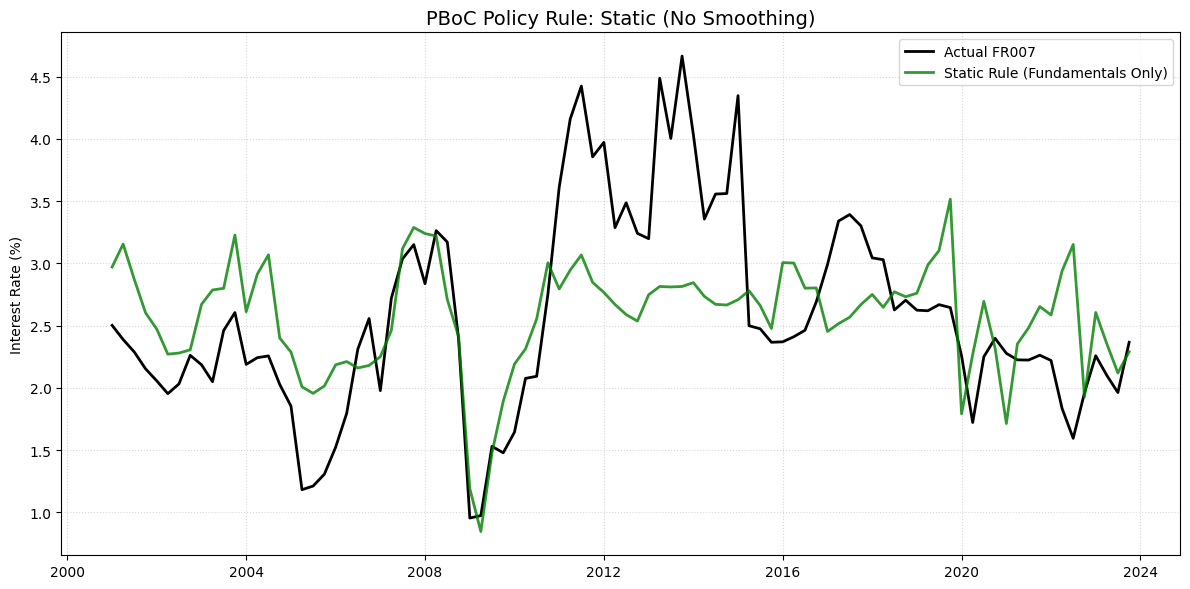

In [165]:
# 4. Plot
plt.figure(figsize=(12, 6))

# Actual
plt.plot(df_zoom.index.to_timestamp(), df_zoom['FR007'], 
         label='Actual FR007', color='black', linewidth=2)

# Static Prediction
plt.plot(df_zoom.index.to_timestamp(), df_zoom['fr007_static'], 
         label='Static Rule (Fundamentals Only)', color='green', linestyle='-', linewidth=2, alpha=0.8)

plt.title('PBoC Policy Rule: Static (No Smoothing)', fontsize=14)
plt.ylabel('Interest Rate (%)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig("Monetary Policy Rule_Static.png", dpi=300)
plt.show()

In [ ]:
df_plot